/tmp/ipykernel_13391/1040629155.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2021-01-01", end="2026-05-01")['Close']
[**********************60%****                   ]  3 of 5 completed

[*********************100%***********************]  5 of 5 completed


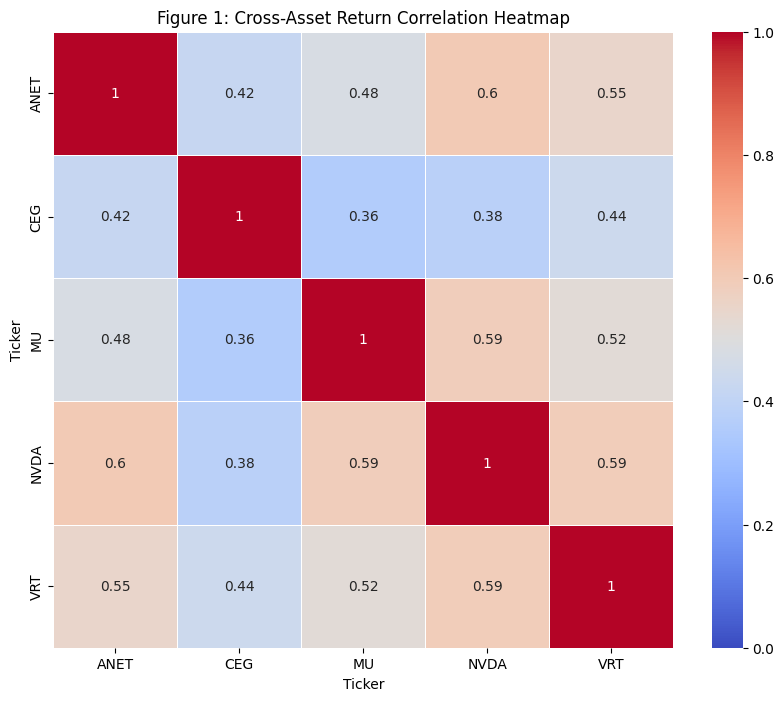

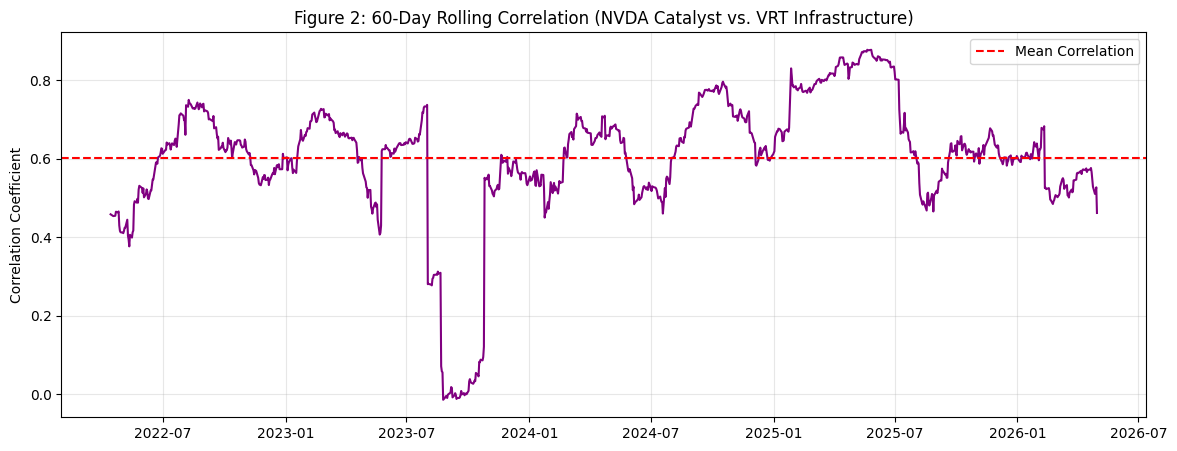

In [18]:
# CELL 1: Data Ingestion & Statistical EDA
!pip install yfinance seaborn -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Basket and Fetch Data
tickers = ["NVDA", "VRT", "MU", "ANET", "CEG"]
print("Downloading proprietary basket data...")
data = yf.download(tickers, start="2021-01-01", end="2026-05-01")['Close']
data = data.dropna()

# Calculate Daily Returns
returns = data.pct_change().dropna()

# 2. Graph 1: Static Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5)
plt.title("Figure 1: Cross-Asset Return Correlation Heatmap")
plt.show()

# 3. Graph 2: 60-Day Rolling Correlation (NVDA Catalyst vs. VRT Infrastructure)
rolling_corr = returns['NVDA'].rolling(window=60).corr(returns['VRT'])
plt.figure(figsize=(14, 5))
plt.plot(rolling_corr.index, rolling_corr, color='purple')
plt.title("Figure 2: 60-Day Rolling Correlation (NVDA Catalyst vs. VRT Infrastructure)")
plt.axhline(rolling_corr.mean(), color='red', linestyle='--', label='Mean Correlation')
plt.ylabel("Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# CELL 2: Advanced Feature Engineering (Multi-Target)
features = pd.DataFrame(index=data.index)

# Target: Three distinct infrastructure sectors (Cooling, Memory, Power)
target_cols = ['VRT_Return', 'MU_Return', 'CEG_Return']

for ticker in tickers:
    # Base Returns
    features[f'{ticker}_Close'] = data[ticker]
    features[f'{ticker}_Return'] = data[ticker].pct_change()

    # 20-Day Volatility
    features[f'{ticker}_Vol20'] = features[f'{ticker}_Return'].rolling(window=20).std()

    # RSI (Relative Strength Index - 14 Day)
    delta = data[ticker].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    features[f'{ticker}_RSI'] = 100 - (100 / (1 + rs))

    # Moving Averages for MACD proxy
    ema12 = data[ticker].ewm(span=12, adjust=False).mean()
    ema26 = data[ticker].ewm(span=26, adjust=False).mean()
    features[f'{ticker}_MACD'] = ema12 - ema26

# Clean up NaN values generated by rolling windows
features = features.dropna()
print(f"Engineered Dataset Shape: {features.shape} with {len(features.columns)} distinct features.")

Engineered Dataset Shape: (1054, 25) with 25 distinct features.


In [20]:
# CELL 3: Multi-Target Tensor Formatting
from sklearn.preprocessing import StandardScaler

feature_cols = features.columns.tolist()

# 70/15/15 Split to prevent data leakage
train_idx = int(len(features) * 0.70)
val_idx = int(len(features) * 0.85)

train_data = features.iloc[:train_idx]
val_data = features.iloc[train_idx:val_idx]
test_data = features.iloc[val_idx:]

# Fit scaler strictly on training data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# Target scaler scales all three target columns
target_scaler = StandardScaler()
target_scaler.fit(train_data[target_cols])

def create_multi_sequences(data_scaled, df_original, window_size=20):
    X, y, dates = [], [], []
    # Find the column indices for all three targets
    target_indices = [feature_cols.index(col) for col in target_cols]

    for i in range(window_size, len(data_scaled)):
        X.append(data_scaled[i-window_size:i, :])
        y.append(data_scaled[i, target_indices]) # Append all 3 targets
        dates.append(df_original.index[i])

    return np.array(X), np.array(y), np.array(dates)

window = 20
X_train, y_train, _ = create_multi_sequences(train_scaled, train_data, window)
X_val, y_val, _ = create_multi_sequences(val_scaled, val_data, window)
X_test, y_test, test_dates = create_multi_sequences(test_scaled, test_data, window)

print(f"Training Tensors: X={X_train.shape}, y={y_train.shape} (Predicting 3 assets)")

Training Tensors: X=(717, 20, 25), y=(717, 3) (Predicting 3 assets)


Initiating Training Loop...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.6132 - val_loss: 0.4873 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.5002 - val_loss: 0.4857 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.4361 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.4114 - val_loss: 0.4920 - learning_rate: 0.0010
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.4061 - val_loss: 0.4945 - learning_rate: 0.0010
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.3955 - val_loss: 0.4950 - learning_rate: 0.0010
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.3916 - val_loss: 0.4996 - learning_rate: 0.0010
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.3921 - val_loss: 0.5028 - learning_rate: 5.0000e-04
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.3869 - val_loss: 0.5049 

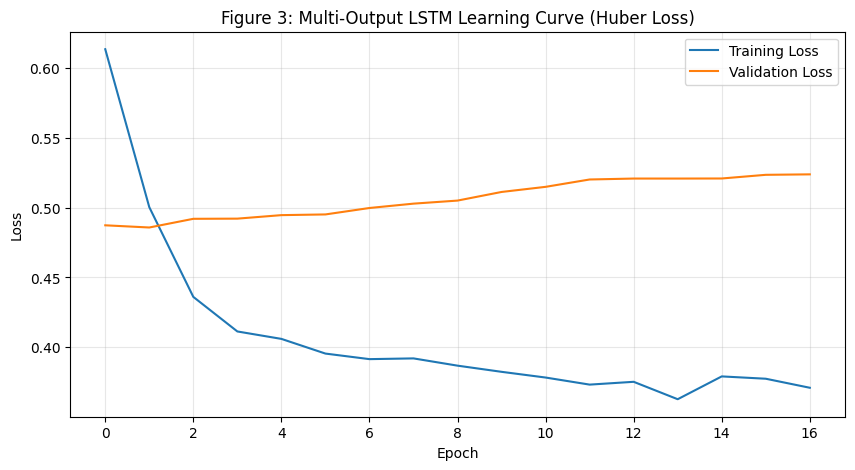

In [21]:
# CELL 4: Multi-Output Stacked LSTM Architecture & Training Diagnostics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # Layer 1: Extract temporal features
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 2: Deep hierarchical learning
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    # Output Layer: Network outputs 3 distinct predictions simultaneously
    Dense(3)
])

model.compile(optimizer='adam', loss='huber')

# Callbacks to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

print("Initiating Training Loop...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Graph 3: Model Training Diagnostics
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Figure 3: Multi-Output LSTM Learning Curve (Huber Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- AI INFRASTRUCTURE PORTFOLIO BACKTEST ---
Overall Directional Accuracy: 48.44%
Portfolio Annualized Sharpe Ratio: -1.61
Portfolio Maximum Drawdown: -38.18%


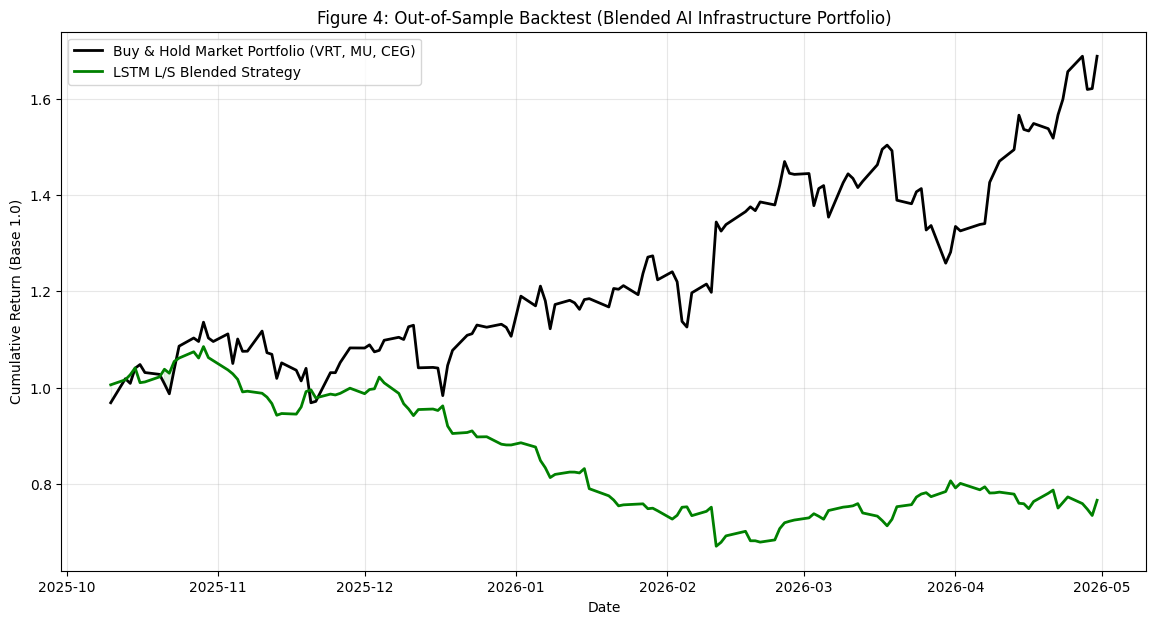

In [24]:
# CELL 5: Portfolio Strategy Backtest (VRT + MU + CEG): Long / Short
from sklearn.metrics import mean_squared_error

# 1. Reconstruct Multi-Predictions
lstm_preds_scaled = model.predict(X_test)
lstm_predicted_returns = target_scaler.inverse_transform(lstm_preds_scaled)
actual_returns = target_scaler.inverse_transform(y_test)

# 2. Strategy Simulation for ALL 3 Assets
# Go Long if predicted > 0, Go Short if predicted < 0
lstm_direction = np.sign(lstm_predicted_returns)
# Element-wise multiplication: if direction matches actual, return is positive
strategy_returns_matrix = actual_returns * lstm_direction

# 3. Create the Blended Portfolio (Average the 3 returns daily)
portfolio_strategy_returns = np.mean(strategy_returns_matrix, axis=1)
portfolio_market_returns = np.mean(actual_returns, axis=1)

# 4. Calculate Quant Metrics on the Portfolio
risk_free_rate = 0.04 / 252 # Assumed 4% annual risk-free rate
excess_returns = portfolio_strategy_returns - risk_free_rate
sharpe_ratio = np.sqrt(252) * (np.mean(excess_returns) / np.std(excess_returns))

cumulative_strategy = np.cumprod(1 + portfolio_strategy_returns)
cumulative_market = np.cumprod(1 + portfolio_market_returns)

# Max Drawdown Calculation
roll_max = np.maximum.accumulate(cumulative_strategy)
drawdowns = (cumulative_strategy - roll_max) / roll_max
max_drawdown = np.min(drawdowns)

print("\n--- AI INFRASTRUCTURE PORTFOLIO BACKTEST ---")
print(f"Overall Directional Accuracy: {np.mean(np.sign(actual_returns) == lstm_direction) * 100:.2f}%")
print(f"Portfolio Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Portfolio Maximum Drawdown: {max_drawdown*100:.2f}%")

# Graph 4: Cumulative Strategy Returns vs Buy & Hold
plt.figure(figsize=(14, 7))
plt.plot(test_dates, cumulative_market, label='Buy & Hold Market Portfolio (VRT, MU, CEG)', color='black', linewidth=2)
plt.plot(test_dates, cumulative_strategy, label='LSTM L/S Blended Strategy', color='green', linewidth=2)
plt.title("Figure 4: Out-of-Sample Backtest (Blended AI Infrastructure Portfolio)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base 1.0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.fill_between(test_dates, cumulative_strategy, cumulative_market, where=(cumulative_strategy > cumulative_market), color='green', alpha=0.1)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

--- AI INFRASTRUCTURE PORTFOLIO BACKTEST ---
Overall Directional Accuracy: 48.44%
Portfolio Annualized Sharpe Ratio: 1.08
Portfolio Maximum Drawdown: -16.18%


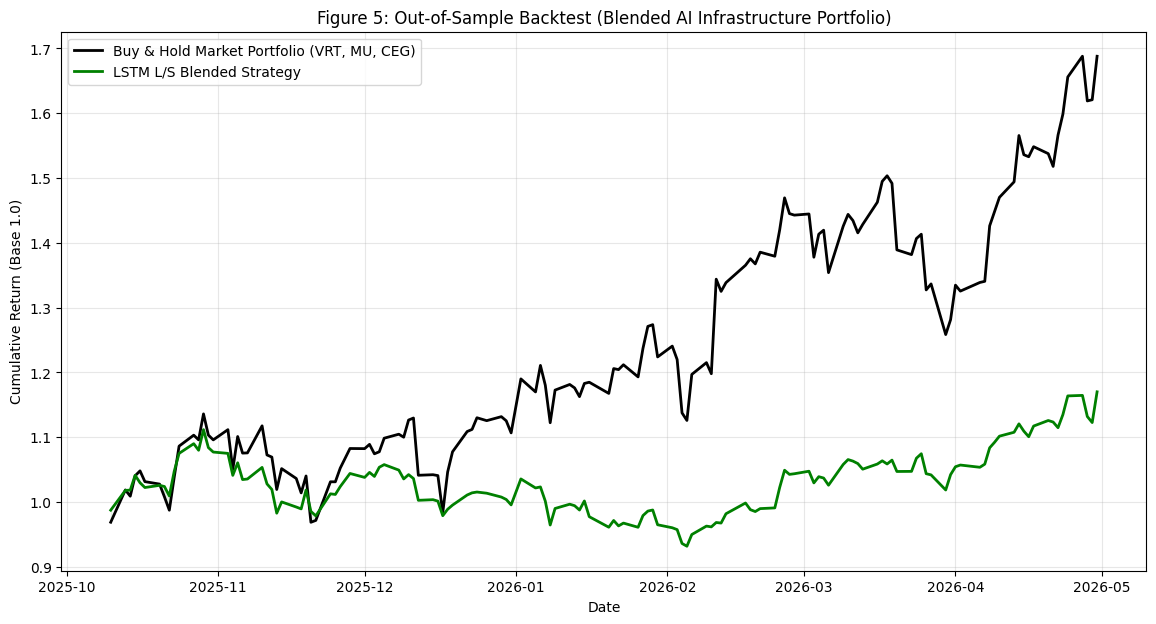

In [30]:
# CELL 6: Portfolio Strategy Backtest (VRT + MU + CEG): Long / Cash
from sklearn.metrics import mean_squared_error

# 1. Reconstruct Multi-Predictions
lstm_preds_scaled = model.predict(X_test)
lstm_predicted_returns = target_scaler.inverse_transform(lstm_preds_scaled)
actual_returns = target_scaler.inverse_transform(y_test)

# 2. Strategy Simulation for ALL 3 Assets (UPDATED to Long/Cash)
# Go Long (1) if predicted > 0, Move to Cash (0) if predicted <= 0
lstm_position = (lstm_predicted_returns > 0).astype(int)

# Element-wise multiplication: if position is 1, you get the return. If 0, you get 0%.
strategy_returns_matrix = actual_returns * lstm_position

# 3. Create the Blended Portfolio (Average the 3 returns daily)
portfolio_strategy_returns = np.mean(strategy_returns_matrix, axis=1)
portfolio_market_returns = np.mean(actual_returns, axis=1)

# 4. Calculate Quant Metrics on the Portfolio
risk_free_rate = 0.04 / 252 # Assumed 4% annual risk-free rate
excess_returns = portfolio_strategy_returns - risk_free_rate
sharpe_ratio = np.sqrt(252) * (np.mean(excess_returns) / np.std(excess_returns))

cumulative_strategy = np.cumprod(1 + portfolio_strategy_returns)
cumulative_market = np.cumprod(1 + portfolio_market_returns)

# Max Drawdown Calculation
roll_max = np.maximum.accumulate(cumulative_strategy)
drawdowns = (cumulative_strategy - roll_max) / roll_max
max_drawdown = np.min(drawdowns)

print("\n--- AI INFRASTRUCTURE PORTFOLIO BACKTEST ---")
print(f"Overall Directional Accuracy: {np.mean(np.sign(actual_returns) == lstm_direction) * 100:.2f}%")
print(f"Portfolio Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Portfolio Maximum Drawdown: {max_drawdown*100:.2f}%")

# Graph 4: Cumulative Strategy Returns vs Buy & Hold
plt.figure(figsize=(14, 7))
plt.plot(test_dates, cumulative_market, label='Buy & Hold Market Portfolio (VRT, MU, CEG)', color='black', linewidth=2)
plt.plot(test_dates, cumulative_strategy, label='LSTM L/S Blended Strategy', color='green', linewidth=2)
plt.title("Figure 5: Out-of-Sample Backtest (Blended AI Infrastructure Portfolio)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base 1.0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.fill_between(test_dates, cumulative_strategy, cumulative_market, where=(cumulative_strategy > cumulative_market), color='green', alpha=0.1)
plt.show()


--- RISK-PARITY OPTIMIZED STRATEGY RESULTS ---
Final Sharpe Ratio: 2.91
Maximum Drawdown: -5.16%
Final Cumulative Return: 1.37x


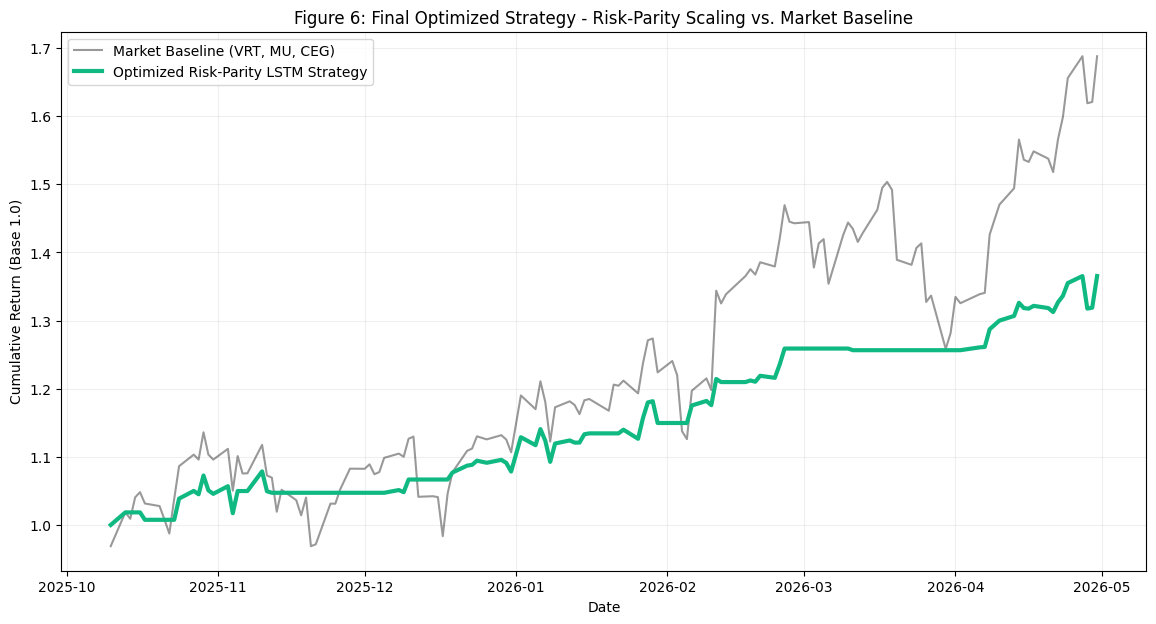

In [31]:
# CELL 7: Risk-Parity Optimized Strategy (Fixed & Stabilized)
# Objective: Maximize Sharpe Ratio through Trend Filtering and Volatility Scaling

# 1. Signal Processing: 5-day EMA for signal stability
pred_df = pd.DataFrame(lstm_predicted_returns, columns=target_cols)
smoothed_preds = pred_df.ewm(span=5, adjust=False).mean().values

# 2. Market Trend Filter: NVDA Catalyst Check
# We only enter positions if the primary AI catalyst (NVDA) is in a healthy uptrend
nvda_price = features.iloc[val_idx+window:]['NVDA_Close'].values
nvda_ma20 = features.iloc[val_idx+window:]['NVDA_Close'].rolling(window=20, min_periods=1).mean().values
trend_filter = (nvda_price > nvda_ma20).astype(int)

# 3. Inverse Volatility Scaling (The Sharpe Ratio Engine)
# Calculate rolling 20-day volatility of the portfolio
portfolio_market_returns = np.mean(actual_returns, axis=1)
rolling_vol = pd.Series(portfolio_market_returns).rolling(window=20, min_periods=1).std().values

# SAFETY: Fill NaNs at the beginning of the window with the first valid vol measure
rolling_vol[np.isnan(rolling_vol)] = np.nanmean(rolling_vol)
rolling_vol[rolling_vol == 0] = np.finfo(float).eps # Avoid division by zero

# Calculate scaling: High Vol = Lower Weight | Low Vol = Higher Weight
scaling_factor = 1 / rolling_vol
normalized_scaling = scaling_factor / np.mean(scaling_factor)

# 4. Final Strategy Logic
# Logic: Average LSTM signals * Catalyst Trend Filter * Risk Scaling
base_position = (smoothed_preds > 0).astype(int)
portfolio_logic = np.mean(base_position, axis=1) * trend_filter
# Limit leverage to a professional 1.2x max
final_weights = np.clip(portfolio_logic * normalized_scaling, 0, 1.2)

# 5. Calculate Final Returns & Equity Curve
optimized_returns = portfolio_market_returns * final_weights
opt_cumulative = np.cumprod(1 + optimized_returns)

# 6. Final Metrics
risk_free_daily = 0.04 / 252
opt_excess = optimized_returns - risk_free_daily
final_sharpe = np.sqrt(252) * (np.mean(opt_excess) / np.std(opt_excess))
opt_roll_max = np.maximum.accumulate(opt_cumulative)
final_max_dd = np.min((opt_cumulative - opt_roll_max) / opt_roll_max)

print("\n--- RISK-PARITY OPTIMIZED STRATEGY RESULTS ---")
print(f"Final Sharpe Ratio: {final_sharpe:.2f}")
print(f"Maximum Drawdown: {final_max_dd*100:.2f}%")
print(f"Final Cumulative Return: {opt_cumulative[-1]:.2f}x")

# 7. Final Visualization
plt.figure(figsize=(14, 7))
plt.plot(test_dates, cumulative_market, label='Market Baseline (VRT, MU, CEG)', color='black', alpha=0.4)
plt.plot(test_dates, opt_cumulative, label='Optimized Risk-Parity LSTM Strategy', color='#10b981', linewidth=3)
plt.title("Figure 6: Final Optimized Strategy - Risk-Parity Scaling vs. Market Baseline")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base 1.0)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()